In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df_c = pd.read_csv('child.csv')
df_p = pd.read_csv('parent.csv')

In [5]:
len(df_c), len(df_p)

(1001, 1001)

In [6]:
# change the age records with only extract numbers
df_c['user_age'] = df_c['user_age'].str.extract('(\d+)')
df_p['user_age'] = df_p['user_age'].str.extract('(\d+)')

In [7]:
# Convert age keys to integers for correct numeric sorting
age_child = {int(k): v for k, v in df_c['user_age'].value_counts().to_dict().items()}
age_parent = {int(k): v for k, v in df_p['user_age'].value_counts().to_dict().items()}

# Sort by age (numeric)
age_child = dict(sorted(age_child.items()))
age_parent = dict(sorted(age_parent.items()))

# Print age distribution
print("Child Age Distribution:")
total_children = sum(age_child.values())
for age, count in age_child.items():
    print(f"Age {age}: {count} children")
print(f"Total children: {total_children}")

print("\nParent Age Distribution:")
total_parents = sum(age_parent.values())
for age, count in age_parent.items():
    print(f"Age {age}: {count} parents")
print(f"Total parents: {total_parents}")

Child Age Distribution:
Age 2: 11 children
Age 3: 3 children
Age 4: 4 children
Age 5: 12 children
Age 6: 26 children
Age 7: 38 children
Age 8: 56 children
Age 9: 82 children
Age 10: 160 children
Age 11: 136 children
Age 12: 123 children
Age 13: 215 children
Age 14: 67 children
Age 15: 33 children
Age 16: 10 children
Age 17: 8 children
Age 18: 16 children
Total children: 1000

Parent Age Distribution:
Age 1: 1 parents
Age 2: 41 parents
Age 3: 9 parents
Age 4: 24 parents
Age 5: 49 parents
Age 6: 74 parents
Age 7: 87 parents
Age 8: 129 parents
Age 9: 75 parents
Age 10: 123 parents
Age 11: 45 parents
Age 12: 59 parents
Age 13: 70 parents
Age 14: 25 parents
Age 15: 21 parents
Age 16: 28 parents
Age 17: 10 parents
Age 18: 130 parents
Total parents: 1000


/tmp/ipykernel_1415956/2552343309.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


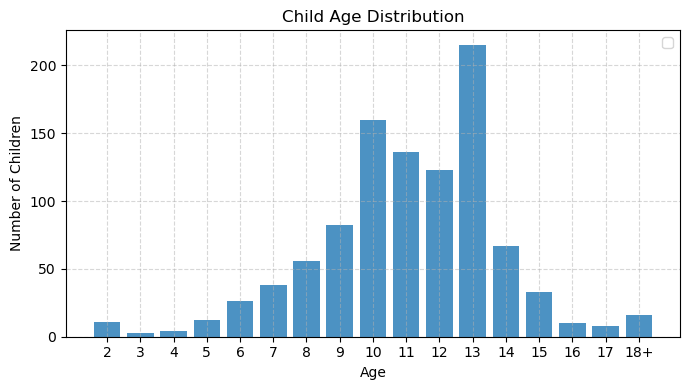

/tmp/ipykernel_1415956/2552343309.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


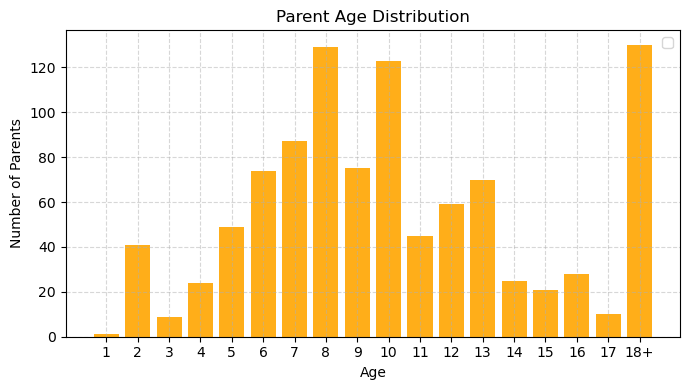

In [8]:
# Convert to pandas Series for plotting
child_series = pd.Series(age_child).sort_index()
parent_series = pd.Series(age_parent).sort_index()

# Rename 18 to '18+' and convert all indices to string for plotting
child_series.index = child_series.index.map(lambda x: '18+' if x == 18 else str(x))
parent_series.index = parent_series.index.map(lambda x: '18+' if x == 18 else str(x))

# Plot child age distribution
plt.figure(figsize=(7, 4))
plt.bar(child_series.index, child_series.values, alpha=0.8)
# plt.plot(child_series.index, child_series.values, marker='o', linestyle='-', label='Child Age Distribution')
plt.title('Child Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Children')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('child_age_distribution.png', dpi=300)
plt.show()

# Plot parent age distribution
plt.figure(figsize=(7, 4))
plt.bar(parent_series.index, parent_series.values, alpha=0.9, color='orange')
# plt.plot(parent_series.index, parent_series.values, marker='o', linestyle='-', label='Parent Age Distribution', color='red')
plt.title('Parent Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Parents')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('parent_age_distribution.png', dpi=300)
plt.show()

In [9]:
# A function to find the number of risk codes in a given column

risk_list = ['violence', 'moderation', 'scam', 'bullying', 'dating', 'sexual game', 'explicit', 'purchases', 'strangers', 'hacking', 'horror', 'addiction', 'discrimination',
              'bypass', 'child-generated', 'verify', 'developer']

def find_risk_codes(dataframe):
    # lower case the risk codes
    dataframe['risk code'] = dataframe['risk code'].str.lower()
    num = len(dataframe)
    dict_risk = {} # store the risk codes and their counts
    # check if each risk appears in the 'risk code' column
    for risk in risk_list:
        count = dataframe['risk code'].str.contains(risk).sum()
        dict_risk[risk] = count
    # sort the dictionary by value in descending order
    dict_risk = dict(sorted(dict_risk.items(), key=lambda item: item[1], reverse=True))
    # print the risk codes and their counts
    for risk, count in dict_risk.items():
        print(f"{risk}: {count} ({count/num:.2%})")
    return dict_risk


In [10]:
risk_child = find_risk_codes(df_c)

violence: 282 (28.17%)
bullying: 227 (22.68%)
scam: 203 (20.28%)
dating: 200 (19.98%)
sexual game: 172 (17.18%)
moderation: 150 (14.99%)
explicit: 109 (10.89%)
hacking: 100 (9.99%)
strangers: 78 (7.79%)
horror: 51 (5.09%)
purchases: 40 (4.00%)
bypass: 35 (3.50%)
discrimination: 24 (2.40%)
child-generated: 16 (1.60%)
verify: 4 (0.40%)
addiction: 0 (0.00%)
developer: 0 (0.00%)


In [11]:
risk_parent = find_risk_codes(df_p)

violence: 236 (23.58%)
sexual game: 180 (17.98%)
bullying: 165 (16.48%)
purchases: 138 (13.79%)
moderation: 134 (13.39%)
dating: 130 (12.99%)
scam: 109 (10.89%)
explicit: 89 (8.89%)
strangers: 78 (7.79%)
horror: 64 (6.39%)
addiction: 62 (6.19%)
hacking: 57 (5.69%)
child-generated: 27 (2.70%)
discrimination: 23 (2.30%)
developer: 8 (0.80%)
bypass: 0 (0.00%)
verify: 0 (0.00%)


In [12]:
# Age groups: 0-5 Infant, 6-12 Child, 13-17 Teenager, 18+ Adult
age_groups = {
    '0-5: Infant': (0, 5),
    '6-12: Child': (6, 12),
    '13-17: Teenager': (13, 17),
    '18+: Adult': (18, 100)  # Assuming 100 as a reasonable upper limit for adults
}

In [13]:
# check the top 5 risk codes for each age group
for age_group, (start_age, end_age) in age_groups.items():
    # skip the NaN values in the user_age column
    df_c['user_age'] = pd.to_numeric(df_c['user_age'], errors='coerce')
    df_p['user_age'] = pd.to_numeric(df_p['user_age'], errors='coerce')

    print("\nFinding risk codes for age group:", age_group)
    child_age_group = df_c[(df_c['user_age'] >= start_age) & (df_c['user_age'] <= end_age)]
    parent_age_group = df_p[(df_p['user_age'] >= start_age) & (df_p['user_age'] <= end_age)]

    print("==========Children Perspective===========")
    find_risk_codes(child_age_group)

    print("\n==========Parents Perspective===========")
    find_risk_codes(parent_age_group)

/tmp/ipykernel_1415956/646478024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['risk code'] = dataframe['risk code'].str.lower()



Finding risk codes for age group: 0-5: Infant
==========Children Perspective===========
violence: 5 (16.67%)
sexual game: 5 (16.67%)
scam: 4 (13.33%)
bullying: 4 (13.33%)
dating: 3 (10.00%)
hacking: 2 (6.67%)
moderation: 1 (3.33%)
explicit: 1 (3.33%)
purchases: 1 (3.33%)
strangers: 1 (3.33%)
horror: 1 (3.33%)
addiction: 0 (0.00%)
discrimination: 0 (0.00%)
bypass: 0 (0.00%)
child-generated: 0 (0.00%)
verify: 0 (0.00%)
developer: 0 (0.00%)

==========Parents Perspective===========
violence: 24 (19.35%)
scam: 16 (12.90%)
bullying: 16 (12.90%)
dating: 15 (12.10%)
moderation: 9 (7.26%)
purchases: 9 (7.26%)
horror: 7 (5.65%)
addiction: 7 (5.65%)
sexual game: 6 (4.84%)
strangers: 5 (4.03%)
explicit: 4 (3.23%)
hacking: 2 (1.61%)
discrimination: 2 (1.61%)
child-generated: 1 (0.81%)
developer: 1 (0.81%)
bypass: 0 (0.00%)
verify: 0 (0.00%)

Finding risk codes for age group: 6-12: Child
==========Children Perspective===========
violence: 175 (28.18%)
scam: 134 (21.58%)
dating: 127 (20.45%)
bullyi

In [14]:
# Calculate it for the whole dataset
print("\n==========Overall Risk Codes===========")
df_total = pd.concat([df_c, df_p], ignore_index=True)
# find_risk_codes(df_total)
for age_group, (start_age, end_age) in age_groups.items():
    print(f"\n=========={age_group}===========")
    df_total['user_age'] = pd.to_numeric(df_total['user_age'], errors='coerce')
    age_group_df = df_total[(df_total['user_age'] >= start_age) & (df_total['user_age'] <= end_age)]
    find_risk_codes(age_group_df)   


==========Overall Risk Codes===========

==========0-5: Infant===========
violence: 29 (18.83%)
scam: 20 (12.99%)
bullying: 20 (12.99%)
dating: 18 (11.69%)
sexual game: 11 (7.14%)
moderation: 10 (6.49%)
purchases: 10 (6.49%)
horror: 8 (5.19%)
addiction: 7 (4.55%)
strangers: 6 (3.90%)
explicit: 5 (3.25%)
hacking: 4 (2.60%)
discrimination: 2 (1.30%)
child-generated: 1 (0.65%)
developer: 1 (0.65%)
bypass: 0 (0.00%)
verify: 0 (0.00%)

==========6-12: Child===========
violence: 314 (25.89%)
bullying: 210 (17.31%)
dating: 196 (16.16%)
scam: 192 (15.83%)
sexual game: 181 (14.92%)
moderation: 146 (12.04%)
purchases: 111 (9.15%)
explicit: 89 (7.34%)
hacking: 88 (7.25%)
strangers: 70 (5.77%)
horror: 57 (4.70%)
addiction: 28 (2.31%)
discrimination: 21 (1.73%)
bypass: 20 (1.65%)
child-generated: 14 (1.15%)
developer: 4 (0.33%)
verify: 3 (0.25%)

==========13-17: Teenager===========
violence: 132 (27.10%)
bullying: 129 (26.49%)
sexual game: 111 (22.79%)
moderation: 101 (20.74%)
dating: 90 (18.48%)

/tmp/ipykernel_1415956/646478024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['risk code'] = dataframe['risk code'].str.lower()


In [ ]:
themes = ['Depictions of Physical Violence', 'Leaking/Scamming Personal Information', 'Bullying, Harassment, and Trolling', 'Gaming Becoming Online Dating', 'Encouragement of Unauthorized Purchases', 'Ineffective Game/Community Moderation']
age_groups = ['0-5', '6-12', '13-17']
# Children data (percentages)
children_data = {
    '0-5': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}
# Parents data (percentages)
parents_data = {
    '0-5': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12': [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17': [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

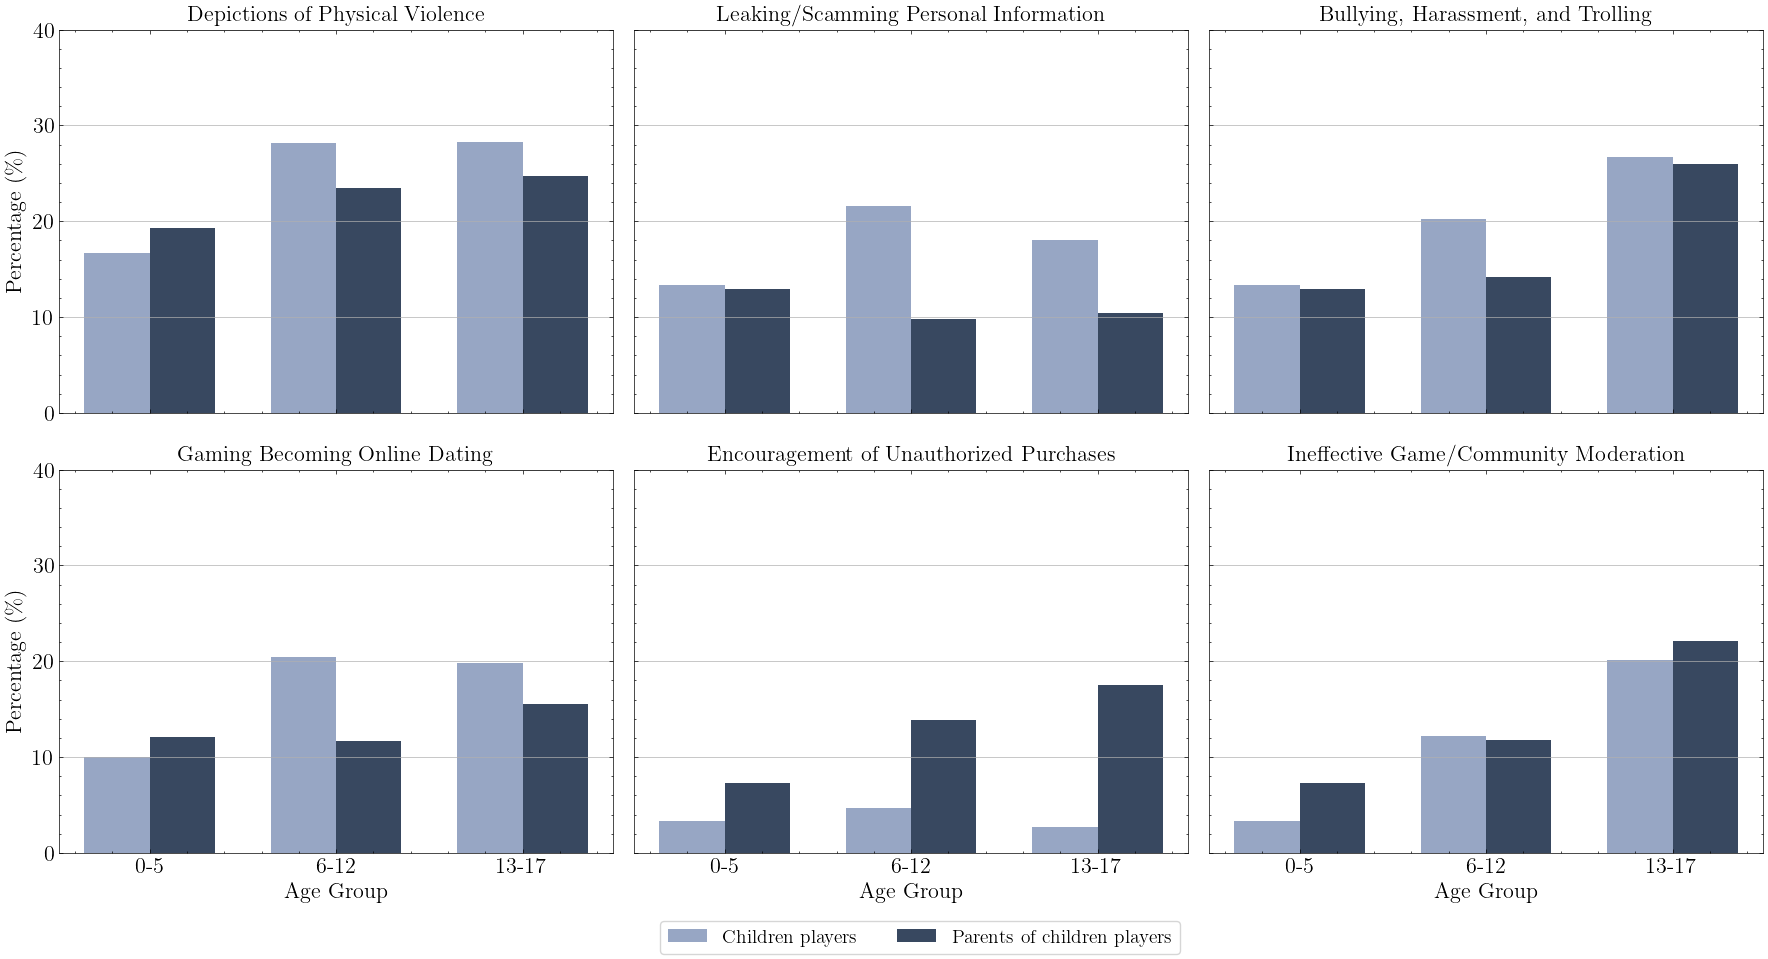

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import scienceplots

plt.style.use('science')

# Set global font sizes (optional but helpful)
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'font.size': 14
})

# Define y-axis formatter to add %
percent_formatter = FuncFormatter(lambda y, _: f'{y:.0f}%')

themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]
age_groups = ['0-5', '6-12', '13-17']
children_data = {
    '0-5': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}
parents_data = {
    '0-5': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12': [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17': [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

x = np.arange(len(age_groups))
width = 0.35

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

legend_handles = []
legend_labels = []

for i, theme in enumerate(themes):
    ax = axes[i]

    children_vals = [children_data[age][i] for age in age_groups]
    parents_vals = [parents_data[age][i] for age in age_groups]

    child_bars = ax.bar(x - width/2, children_vals, width, label='Children players', color='#97a6c4')
    parent_bars = ax.bar(x + width/2, parents_vals, width, label='Parents of children players', color='#384860')

    if i == 0:
        legend_handles = [child_bars[0], parent_bars[0]]
        legend_labels = ['Children players', 'Parents of children players']

    ax.set_title(theme)
    ax.set_ylim(0, 40)
    ax.set_yticks(np.arange(0, 41, 10))
    ax.yaxis.set_major_formatter(percent_formatter)
    ax.set_xticks(x)

    if i >= 3:
        ax.set_xticklabels(age_groups)
        ax.set_xlabel('Age Group')
    else:
        ax.set_xticklabels([])

    if i % 3 == 0:
        ax.set_ylabel('Percentage (\%)')
    else:
        ax.set_yticklabels([])

    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Global legend below all plots
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=2, fontsize=14, frameon=True, bbox_to_anchor=(0.52, 0.02))

# Adjust layout
fig.tight_layout(rect=[0, 0.06, 1, 1])

# Save to PDF
plt.savefig('age_risk_distribution.pdf', dpi=300)
plt.show()


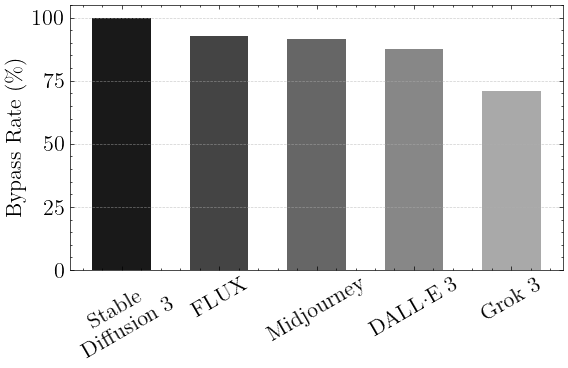

In [72]:
import matplotlib.pyplot as plt

models = ['Stable Diffusion 3', 'FLUX', 'DALL·E 3', 'Grok 3', 'Midjourney']
bypass_rate = {
    'Stable\nDiffusion 3': 100.0,
    'FLUX': 92.8,
    'DALL·E 3': 87.5,
    'Grok 3': 71.0,
    'Midjourney': 91.5,
}

# Define a professional flat color palette (dark to light blue tones)
colors = ['#08306b', '#08519c', '#2171b5', '#4292c6', "#6babd0"]  # Deep blue shades from ColorBrewer's 'Blues'
grayscale_colors = ['#000000', '#2f2f2f', '#555555', '#7a7a7a', '#a0a0a0']
# Sort the models by bypass rate descending
sorted_items = sorted(bypass_rate.items(), key=lambda x: -x[1])
sorted_models = [item[0] for item in sorted_items]
sorted_rates = [item[1] for item in sorted_items]

plt.figure(figsize=(6, 4))
plt.rcParams.update({'font.size': 14})

bars = plt.bar(sorted_models, sorted_rates, width=0.6, color=grayscale_colors, alpha=0.9)

# # Add value labels above bars
# for i, rate in enumerate(sorted_rates):
#     y_offset = 0.5
#     plt.text(i, rate + y_offset, f'{rate:.1f}\%', ha='center', va='bottom',
#              fontsize=13, color='black', fontweight='bold')

# Axis settings
plt.ylabel('Bypass Rate (\%)')
plt.xticks(rotation=30, ha='center')
# plt.xlim(-0.5, len(models) - 0.5)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('bypass_rate.pdf', dpi=300)
plt.show()